In [91]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import seaborn as sns
import pySimpleBrainPlot as sbp
import cairosvg

from io import BytesIO
from PIL import Image
from matplotlib import cm
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu, spearmanr, false_discovery_control

from cat_whim.config import PROCESSED_DATA_DIR, FIGURES_DIR

In [93]:
def check_left_right_differences(df, cols, type_of_col, do_plot=False):

    list_p = []
    list_reg = []

    for region in cols[:34]:

        region_names = region.split("_")

        if "amy" in type_of_col or "tau" in type_of_col:
            
            left_name = region_names[0] + "_LH_" + region_names[2] + "_" + region_names[3] + "_" + region_names[4]
            right_name = region_names[0] + "_RH_" + region_names[2] + "_" + region_names[3] + "_" + region_names[4]
            u, p = mannwhitneyu(df[left_name], df[right_name])
            list_p.append(p)

        else:

            left_name = region_names[0] + "_LH_" + region_names[2] + "_" + region_names[3] # + "_" + region_names[4]
            right_name = region_names[0] + "_RH_" + region_names[2] + "_" + region_names[3] # + "_" + region_names[4]
            u, p = mannwhitneyu(df[left_name], df[right_name])
            list_p.append(p)
        
        reg_name = region_names[2]
        list_reg.append(reg_name)
        

    list_p_corr = false_discovery_control(np.array(list_p))
    where_sig = [p < 0.05 for p in list_p]
    where_sig_corr = [p < 0.05 for p in list_p_corr]

    n_sig = sum(where_sig)
    n_sig_corr = sum(where_sig_corr)

    sig_reg = np.array(list_reg)[where_sig]
    sig_reg_corr = np.array(list_reg)[where_sig_corr]

    print(f"LH vs. RH {type_of_col}: {n_sig} ({n_sig_corr} after FDR) are significantly different")

    if do_plot:
            
        fig, axs = plt.subplots(7, 5, figsize = (10, 8))
        axs_flat = axs.flatten()
        
        for i, region in enumerate(cols[:34]):
            
            region_names = region.split("_")

            if "amy" in type_of_col or "tau" in type_of_col:
            
                left_name = region_names[0] + "_LH_" + region_names[2] + "_" + region_names[3] + "_" + region_names[4]
                right_name = region_names[0] + "_RH_" + region_names[2] + "_" + region_names[3] + "_" + region_names[4]
            
            else:
            
                left_name = region_names[0] + "_LH_" + region_names[2] + "_" + region_names[3] # + "_" + region_names[4]
                right_name = region_names[0] + "_RH_" + region_names[2] + "_" + region_names[3] # + "_" + region_names[4]
            
            sns.histplot(df[left_name], color = "tab:blue", ax = axs_flat[i], alpha = 0.6, bins=20)
            sns.histplot(df[right_name], color = "tab:orange", ax = axs_flat[i], alpha = 0.6, bins=20)
            axs_flat[i].set_xlabel(region_names[2])

        fig.tight_layout()
        plt.show()

    return sig_reg, sig_reg_corr

def plot_exploration(df, df_m00, savefig = False):

    fig, axs = plt.subplots(2, 5, figsize = (12, 6))

    df["session"].hist(ax = axs[0, 0], grid=False)
    sns.boxplot(data=df, x = "session", y = "Years_m00", ax = axs[0, 1], order=["M01", "M02"])
    df_m00["DX"].hist(ax = axs[0, 2], grid=False)
    df_m00["PTGENDER"].hist(ax = axs[0, 3], grid = False)
    df_m00["APOE4"].astype(str).hist(ax = axs[0, 4], grid = False)
    df_m00["PTEDUCAT"].hist(ax = axs[1, 0], grid = False)
    df_m00["MMSE"].hist(ax = axs[1, 1], grid = False)
    df_m00["TRACER_amy"].hist(ax = axs[1, 2], grid = False)
    df_m00["HMHYPERT"].astype(str).hist(ax = axs[1, 3], grid = False)
    df_m00["AMYLOID_STATUS"].hist(ax=axs[1, 4], grid=False)

    axs[0, 0].set_xlabel("Visit")
    axs[0, 1].set_xlabel("Visit")
    axs[0, 2].set_xlabel("Diagnosis")
    axs[0, 3].set_xlabel("Sex")
    axs[0, 4].set_xlabel("APOE4 (n° of alleles)")
    axs[1, 0].set_xlabel("Education (yrs.)")
    axs[1, 1].set_xlabel("MMSE")
    axs[1, 2].set_xlabel("Amyloid tracer")
    axs[1, 3].set_xlabel("Hypertension")
    axs[1, 4].set_xlabel(r"$A\beta$ status")
    
    fig.suptitle("Exploration")
    fig.tight_layout()
    
    if savefig:
        fig.savefig(FIGURES_DIR / "plot_df_exploration.png", dpi = 300)
    
    plt.show()

def my_regplot(data, x, y, ax):
    from scipy.stats import linregress
    sns.regplot(data = data, x = x, y = y, ax = ax, scatter_kws = {"s": 8, "alpha":0.4, "color": "black"}, line_kws={"color": "red"})
    slope, intercept, r, p, stderr = linregress(data[x], data[y])
    ax.set_title(f"r = {r:.2f}, p = {p:.2f}")

def plot_correlation_var_bmrkr(df_m00, group, var, var_name, savefig=False):

    if group == "All":
        
        df_m00 = df_m00.copy()

    else:

        df_m00 = df_m00[df_m00["DX"] == group].copy()

    fig, axs = plt.subplots(1, 4, figsize = (12, 3))

    my_regplot(data = df_m00, x = var, y = "mean_thickness", ax = axs[0])
    my_regplot(data = df_m00, x = var, y = "mean_SUVR_amy", ax = axs[1])
    my_regplot(data = df_m00, x = var, y = "mean_SUVR_tau", ax = axs[2])
    my_regplot(data = df_m00, x = var, y = "mean_disconn", ax = axs[3])

    axs[0].set_xlabel(var_name)
    axs[1].set_xlabel(var_name)
    axs[2].set_xlabel(var_name)
    axs[3].set_xlabel(var_name)

    axs[0].set_ylabel("Mean Cortical Thickness")
    axs[1].set_ylabel("Mean Amyloid SUVR")
    axs[2].set_ylabel("Mean Tau SUVR")
    axs[3].set_ylabel("Mean Disconnection")

    fig.suptitle(group)
    fig.tight_layout()

    if savefig:
        fig.savefig(FIGURES_DIR / f"plot_correlation_{var}_vs_all_biomarkers.png", dpi = 500)

    plt.show()



def plot_group_comparison(data, group_col, group_name, y_cols, pairs, test="Mann-Whitney", figsize=(12, 3)):
    """
    General function to plot group comparisons with statistical annotations.

    Parameters:
    - data: pandas DataFrame, the dataset to use
    - group_col: str, the column name for the grouping variable (e.g., 'APOE4')
    - y_cols: list of str, the columns to plot on the y-axis (e.g., ['mean_thickness', 'mean_SUVR_amy', ...])
    - pairs: list of tuples, the pairs of groups to compare (e.g., [(0, 1), (0, 2), (1, 2)])
    - test: str, the statistical test to use for annotation (default: 'Mann-Whitney')
    - figsize: tuple, the size of the figure (default: (12, 3))
    """

    num_plots = len(y_cols)
    fig, axs = plt.subplots(1, num_plots, figsize=figsize)

    for i, y_col in enumerate(y_cols):
        sns.boxplot(data=data, x=group_col, y=y_col, ax=axs[i])

        # Adding statistical annotations
        annotator = Annotator(data=data, ax=axs[i], pairs=pairs, x=group_col, y=y_col, verbose=0)
        annotator.configure(test=test).apply_and_annotate()

        # Setting labels for each subplot
        axs[i].set_xlabel(group_name)
        axs[i].set_ylabel(y_col.replace("_", " ").title())

    fig.tight_layout()
    plt.show()


def plot_analysis_one_region(df, region_label):

    """This function plots the cross-sectional analysis for a single region label of the dk atlas"""

    region_label_amy = region_label + "_SUVR_amy"
    region_label_tau = region_label + "_SUVR_tau"
    region_label_disconn = region_label + "_disconn"
    region_label_thick = region_label + "_THICKNESS"

    fig, axs = plt.subplots(nrows=2, ncols=3, figsize = (10, 6))

    sns.histplot(data=df, x = region_label_amy, alpha = 0.5, ax = axs[0, 0])
    sns.histplot(data=df, x = region_label_tau, alpha = 0.5, ax = axs[0, 1])
    sns.histplot(data=df, x = region_label_disconn, alpha = 0.5, ax = axs[0, 2])

    my_regplot(data=df, x = region_label_amy, y = region_label_thick, ax = axs[1, 0])
    my_regplot(data=df, x = region_label_tau, y = region_label_thick, ax = axs[1, 1])
    my_regplot(data=df, x = region_label_disconn, y = region_label_thick, ax = axs[1, 2])

    axs[0, 0].set_xlabel('Amyloid') 
    axs[0, 1].set_xlabel('Tau') 
    axs[0, 2].set_xlabel('Disconnectivity') 

    axs[1, 0].set_xlabel('Amyloid') 
    axs[1, 1].set_xlabel('Tau') 
    axs[1, 2].set_xlabel('Disconnectivity') 

    axs[1, 0].set_ylabel('Cort. Thick.') 
    axs[1, 1].set_ylabel('Cort. Thick.') 
    axs[1, 2].set_ylabel('Cort. Thick.') 

    fig.suptitle(region_label)
    fig.tight_layout()


def plot_brain_dk(group, bmrkr, values):
        def post_process_sbp(fig_name):
    
            # Read the saved SVG and convert to PNG
            with open(FIGURES_DIR / fig_name, "rb") as svg_file:
                png_image = cairosvg.svg2png(file_obj=svg_file)

            # Load the PNG image into a PIL Image object
            image = Image.open(BytesIO(png_image))

            # Define the crop box (left, upper, right, lower) to remove the old colorbar which does not update its colors...
            left = 0
            upper = 0
            right = 1000
            lower = 700
            cropped_image = image.crop((left, upper, right, lower))

            # Convert the cropped image back to PNG format for Matplotlib
            cropped_image_bytes = BytesIO()
            cropped_image.save(cropped_image_bytes, format='PNG')
            cropped_image_bytes.seek(0)

            # Load the cropped image into Matplotlib
            brain_image = mpimg.imread(cropped_image_bytes)
            return brain_image
        
        vmin = np.round(values.min(), 2)
        vmax = np.round(values.max(), 2)

        # Plot the brain surface using pySimpleBrainPlot and save as SVG
        sbp.plotBrain('aparc', values, cm="coolwarm", scaling=0.1, vmin=vmin, vmax=vmax, viewer=False, save_path=FIGURES_DIR, save_file=f"{group}_{bmrkr}")
        plt.close()

        brain_image = post_process_sbp(f"{group}_{bmrkr}_aparc.svg")

        # Create the figure
        fig = plt.figure(figsize=(10, 5))

        # Add an axis for the brain image
        ax_img = fig.add_axes([0.1, 0.1, 0.8, 0.8])  # [left, bottom, width, height]

        # Display the cropped brain image on the axis
        ax_img.imshow(brain_image, vmin=0, vmax=255)  # Use 'gray' or appropriate colormap
        ax_img.axis('off')  # Hide axes for the brain image

        # Create a new axis for the colorbar with fixed size
        ax_cbar = fig.add_axes([0.8, 0.3, 0.02, 0.4])  # [left, bottom, width, height]
        # Create a ScalarMappable for the colorbar
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)  # Normalization for the colorbar
        sm = cm.ScalarMappable(cmap="coolwarm", norm=norm)  # Create ScalarMappable for colorbar
        sm.set_array([])  # This is necessary to avoid warnings

        # Plot the colorbar on the fixed-size axis
        cbar = plt.colorbar(sm, cax=ax_cbar, orientation='vertical')
        cbar.set_label(bmrkr, fontsize=12)  # Label the colorbar with the biomarker name

        plt.show()
        plt.savefig(FIGURES_DIR / f"{group}_{bmrkr}_cropped_with_colorbar.png")
        # Close the plot to avoid overlapping issues in the next iteration
        plt.close()


def plot_correlation_biomarkers_ct(df, group, group_label, thickness, is_rate=False):
    
    if group in ["CN", "MCI", "Dementia"]:
        df_to_plot = df[df["DX"] == group].copy()

    else:
        df_to_plot = df.copy()

    
    df_to_plot["amy_tau"] = df_to_plot["SUVR_amy"] * df_to_plot["SUVR_tau"]
    df_to_plot["amy_disconn"] = df_to_plot["SUVR_amy"] * df_to_plot["disconn"]
    df_to_plot["tau_disconn"] = df_to_plot["SUVR_tau"] * df_to_plot["disconn"]
    df_to_plot["amy_tau_disconn"] = df_to_plot["SUVR_tau"] * df_to_plot["SUVR_tau"] * df_to_plot["disconn"]


    fig, axs = plt.subplots(nrows=1, ncols=3, figsize = (10, 3))

    my_regplot(data=df_to_plot, x = "SUVR_amy", y = thickness, ax = axs[0])
    my_regplot(data=df_to_plot, x = "SUVR_tau", y = thickness,  ax = axs[1])
    my_regplot(data=df_to_plot, x = "disconn", y = thickness,  ax = axs[2])

        
    axs[0].set_xlabel("Amyloid (SUVR)")
    axs[1].set_xlabel("Tau (SUVR)")
    axs[2].set_xlabel("Disconnection")

    if not is_rate:

        axs[0].set_ylabel("Cortical Thickness (mm)")
        axs[1].set_ylabel("Cortical Thickness (mm)")
        axs[2].set_ylabel("Cortical Thickness (mm)")
    
    else:
        axs[0].set_ylabel(r"CT (annualized % rate of change)")
        axs[1].set_ylabel(r"CT (annualized % rate of change)")
        axs[2].set_ylabel(r"CT (annualized % rate of change)")

    fig.suptitle(group_label)
    fig.tight_layout()

    fig, axs = plt.subplots(nrows=1, ncols=4, figsize = (12, 3))

    my_regplot(data=df_to_plot, x = "amy_tau", y = thickness, ax = axs[0])
    my_regplot(data=df_to_plot, x = "amy_disconn", y = thickness,  ax = axs[1])
    my_regplot(data=df_to_plot, x = "tau_disconn", y = thickness,  ax = axs[2])
    my_regplot(data=df_to_plot, x = "amy_tau_disconn", y = thickness,  ax = axs[3])

        
    axs[0].set_xlabel("Amyloid*Tau")
    axs[1].set_xlabel("Amyloid*Disconn")
    axs[2].set_xlabel("Tau*Disconn")
    axs[3].set_xlabel("Amyloid*Tau*Disconn")
    
    if not is_rate:

        axs[0].set_ylabel("Cortical Thickness (mm)")
        axs[1].set_ylabel("Cortical Thickness (mm)")
        axs[2].set_ylabel("Cortical Thickness (mm)")
        axs[3].set_ylabel("Cortical Thickness (mm)")

    else:
        axs[0].set_ylabel(r"CT (annualized % rate of change)")
        axs[1].set_ylabel(r"CT (annualized % rate of change)")
        axs[2].set_ylabel(r"CT (annualized % rate of change)")
        axs[3].set_ylabel(r"CT (annualized % rate of change)")

    fig.suptitle(group_label)
    fig.tight_layout()

In [95]:
# Change to df_cat_whim_to_analyze_complete_apoe.csv in case you want only ptids with complete info
df_filename = PROCESSED_DATA_DIR / "df_cat_whim_to_analyze.csv"
df_m00_filename = PROCESSED_DATA_DIR / "df_cat_whim_to_analyze_m00.csv"
df_long_mean_filename = PROCESSED_DATA_DIR / "df_cat_whim_to_analyze_long_format_mean.csv"
df_long_region_filename = PROCESSED_DATA_DIR / "df_cat_whim_to_analyze_long_format_regional.csv"
dk_regions_filename = PROCESSED_DATA_DIR / "dk_region_names.csv"

# Load data
df = pd.read_csv(df_filename)
df_m00 = pd.read_csv(df_m00_filename)
df_long_mean = pd.read_csv(df_long_mean_filename)
df_long_region = pd.read_csv(df_long_region_filename)
dk_region_labels = pd.read_csv(dk_regions_filename).values.flatten()

# Get the region names for each biomarker
amy_cols = [region + "_SUVR_amy" for region in dk_region_labels]
tau_cols = [region + "_SUVR_tau" for region in dk_region_labels]
disconn_cols = [region + "_disconn" for region in dk_region_labels]
thick_cols = [region + "_THICKNESS" for region in dk_region_labels]

# Using the one with some nans in APOE should result in APOE4 being printed, otherwise this should not print anything
for col in df.columns:
    if df[col].isna().any():
        print(col)

APOE4


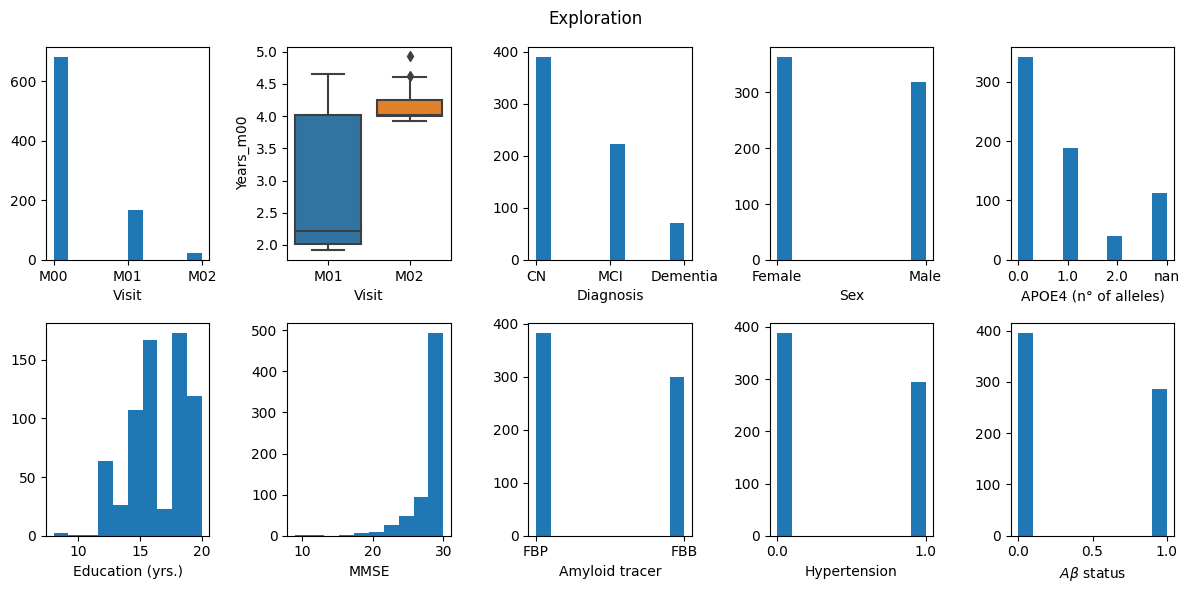

In [5]:
plot_exploration(df, df_m00)

In [6]:
# We will exclude ses-M02 since there are not that many...
df = df[df["session"] != "M02"].copy()

LH vs. RH amy: 9 (4 after FDR) are significantly different


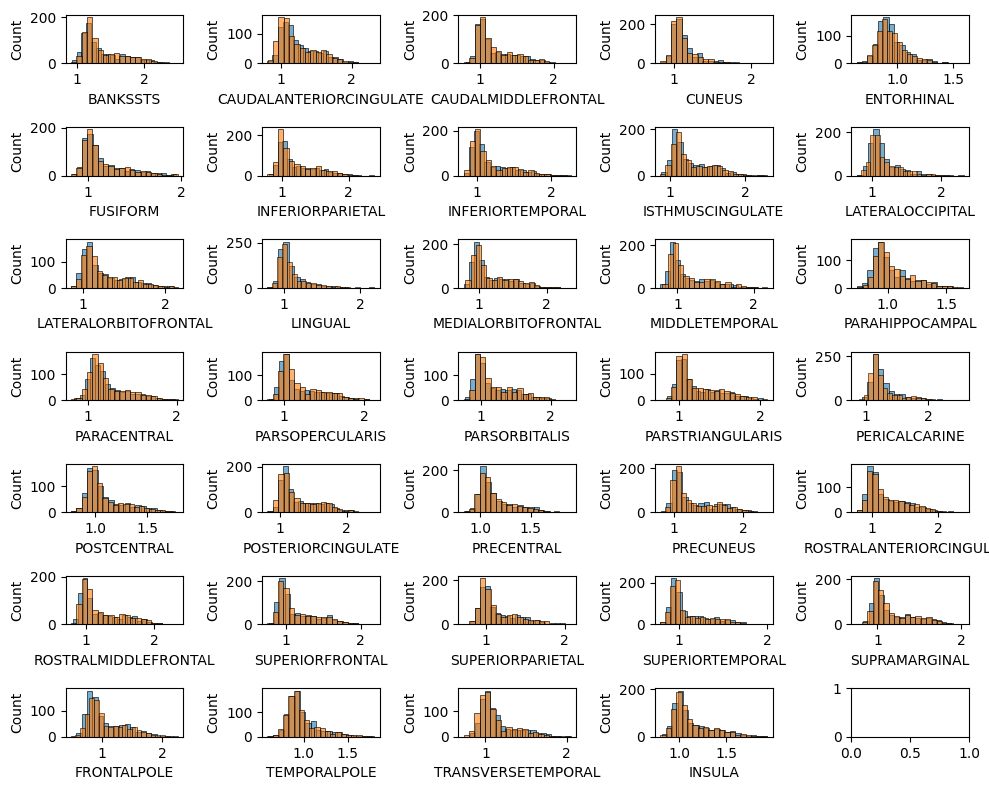

LH vs. RH tau: 7 (4 after FDR) are significantly different


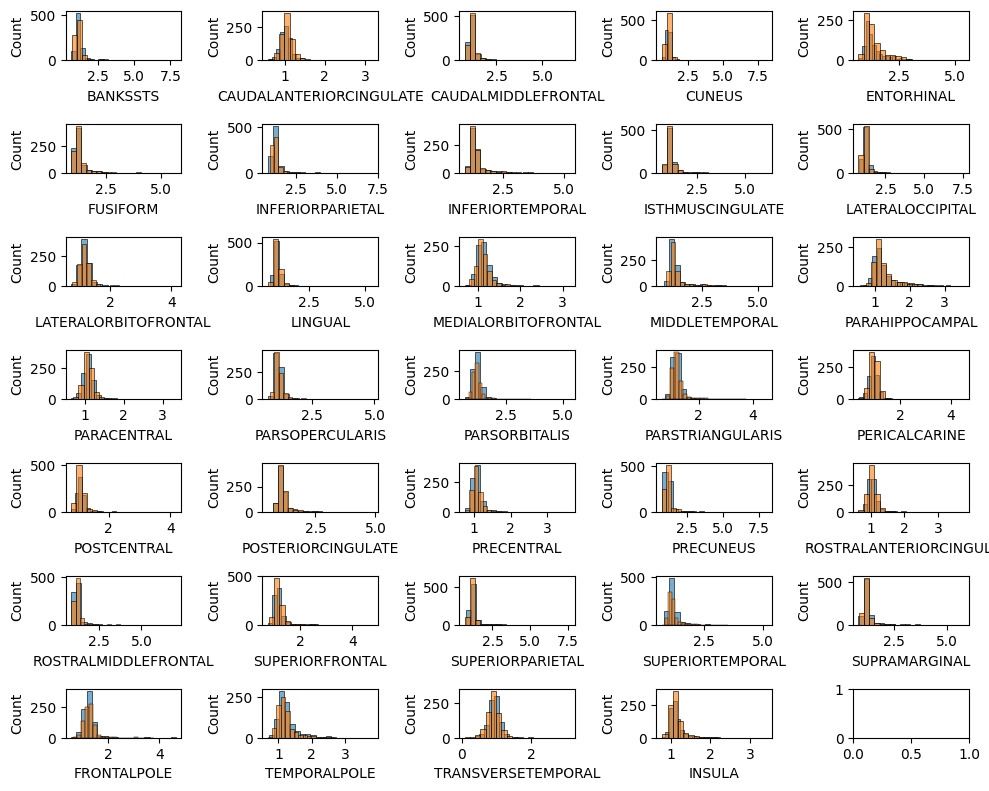

LH vs. RH disconn: 28 (28 after FDR) are significantly different


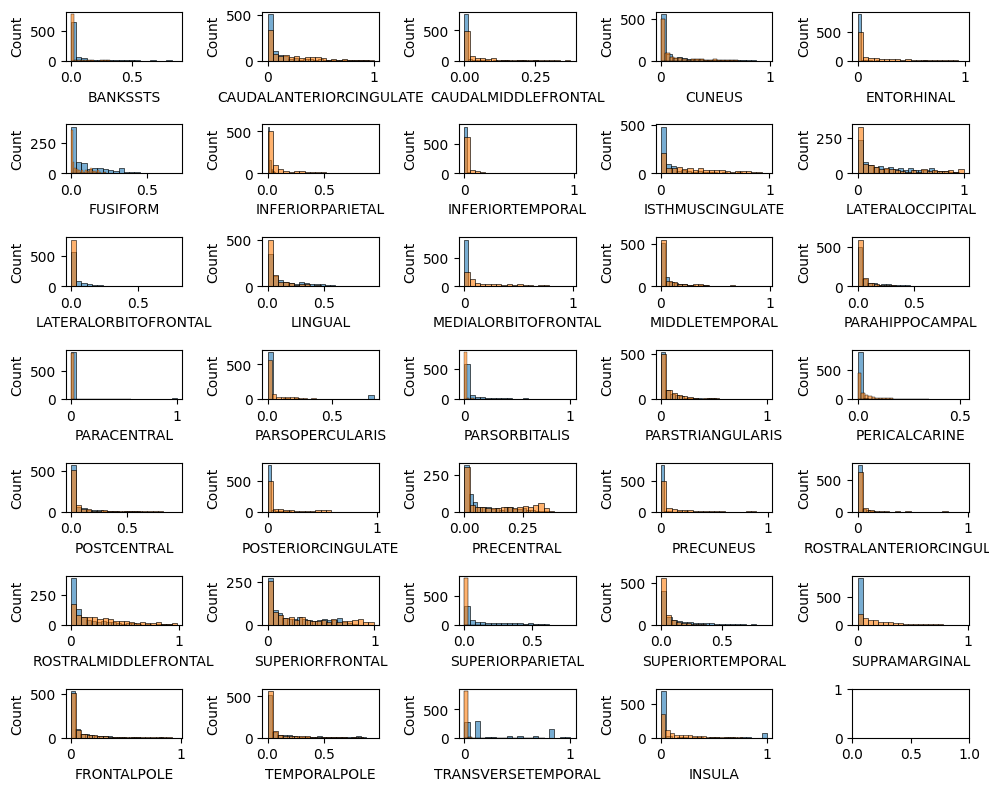

LH vs. RH thickness: 25 (23 after FDR) are significantly different


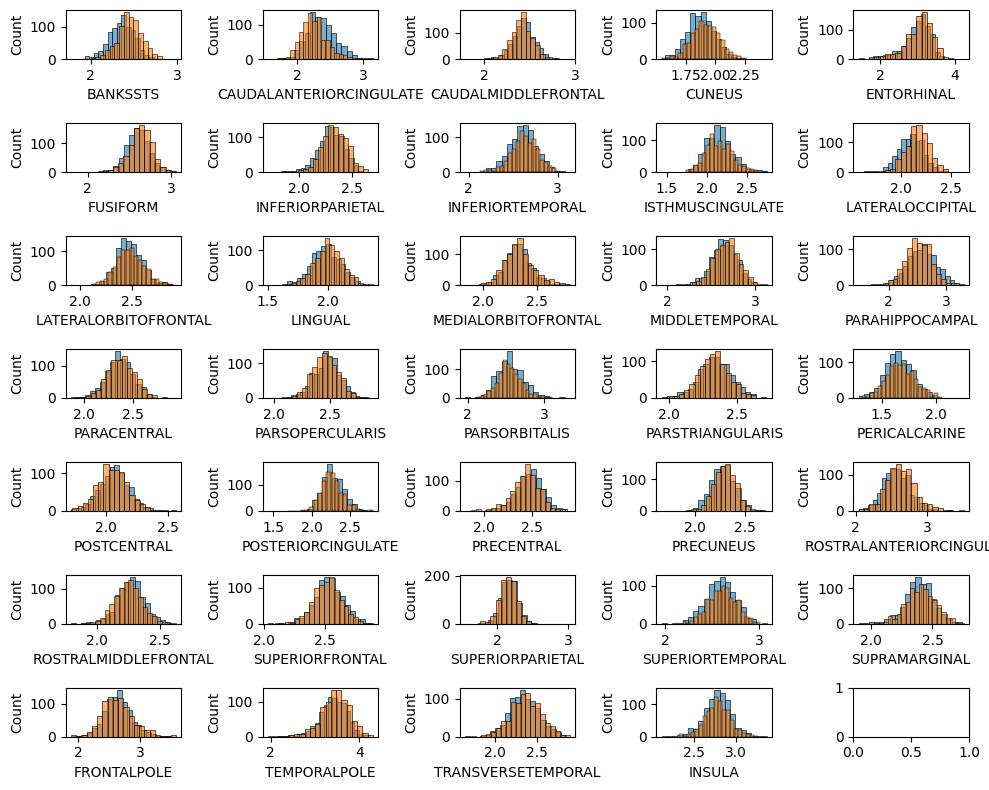

In [7]:
sig_reg_amy, sig_reg_corr_amy = check_left_right_differences(df, amy_cols, "amy", do_plot=True)
sig_reg_tau, sig_reg_corr_tau = check_left_right_differences(df, tau_cols, "tau", do_plot=True)
sig_reg_disconn, sig_reg_corr_disconn = check_left_right_differences(df, disconn_cols, "disconn", do_plot=True)
sig_reg_thickness, sig_reg_corr_thickness = check_left_right_differences(df, thick_cols, "thickness", do_plot=True)

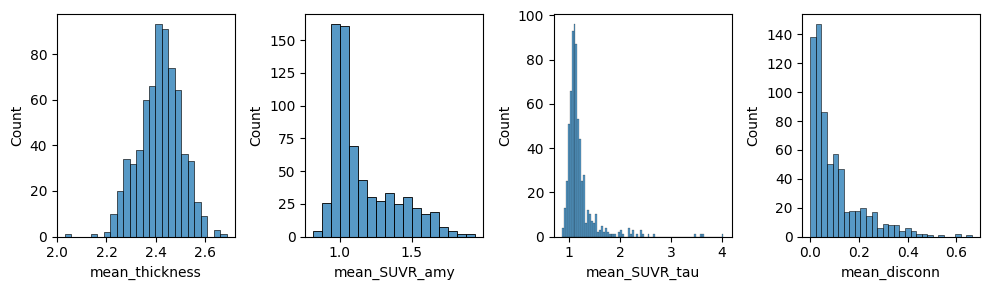

In [8]:
fig, axs = plt.subplots(1, 4, figsize=(10,3))

sns.histplot(data=df_m00, x = "mean_thickness", ax = axs[0])
sns.histplot(data=df_m00, x = "mean_SUVR_amy", ax = axs[1])
sns.histplot(data=df_m00, x = "mean_SUVR_tau", ax = axs[2])
sns.histplot(data=df_m00, x = "mean_disconn", ax = axs[3])

fig.tight_layout()

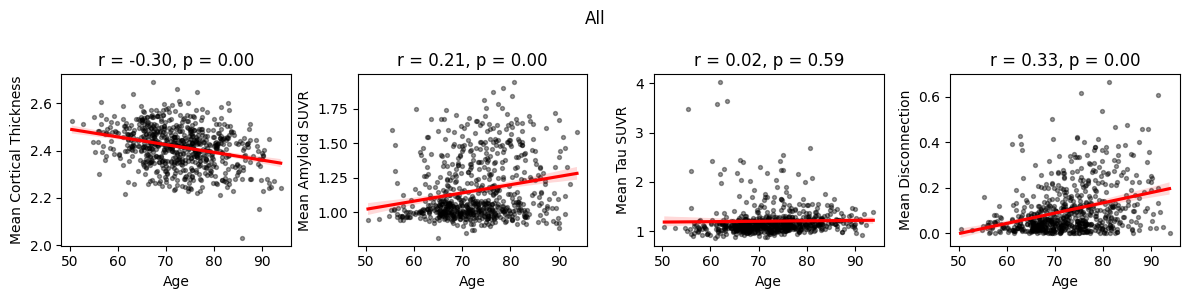

In [9]:
plot_correlation_var_bmrkr(df_m00, "All", "AGE", "Age", savefig=False)

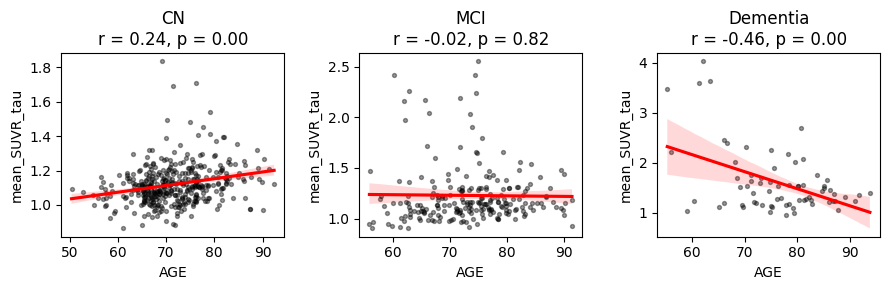

In [10]:
fig, axs = plt.subplots(1, 3, figsize = (9, 3))

my_regplot(data=df_m00[df_m00["DX"] == "CN"], x = "AGE", y = "mean_SUVR_tau", ax = axs[0])
my_regplot(data=df_m00[df_m00["DX"] == "MCI"], x = "AGE", y = "mean_SUVR_tau", ax = axs[1])
my_regplot(data=df_m00[df_m00["DX"] == "Dementia"], x = "AGE", y = "mean_SUVR_tau", ax = axs[2])

title = axs[0].get_title()
axs[0].set_title("CN" + "\n" + title)
title = axs[1].get_title()
axs[1].set_title("MCI" + "\n" + title)
title = axs[2].get_title()
axs[2].set_title("Dementia" + "\n" + title)
fig.tight_layout()

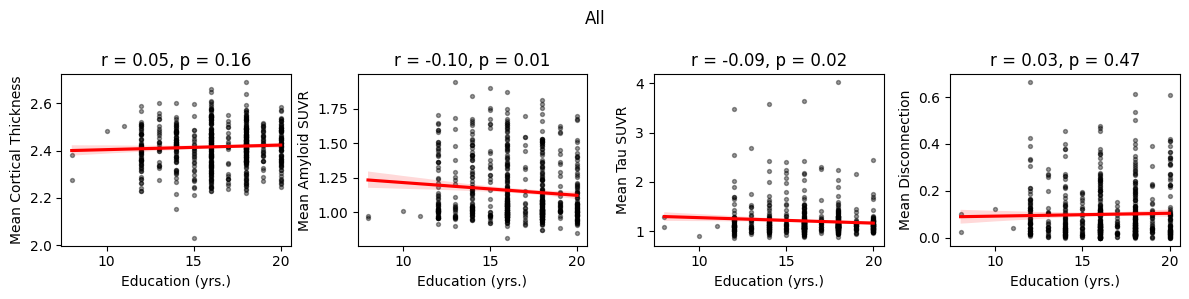

In [12]:
plot_correlation_var_bmrkr(df_m00, "All", "PTEDUCAT", "Education (yrs.)", savefig=False)

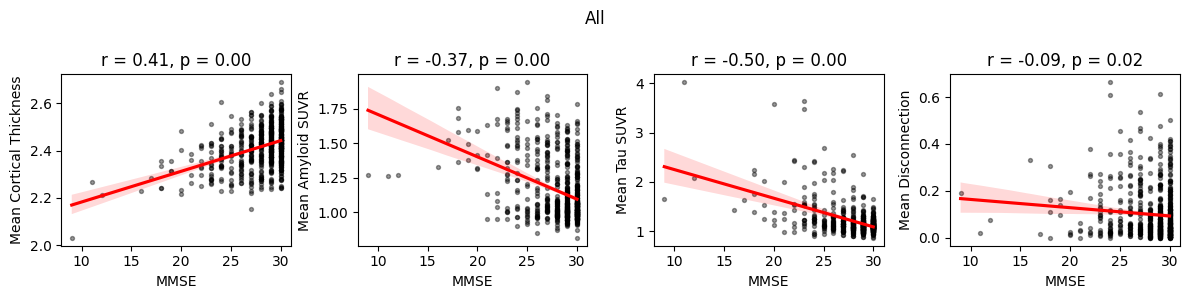

In [13]:
plot_correlation_var_bmrkr(df_m00, "All", "MMSE", "MMSE", savefig=False)

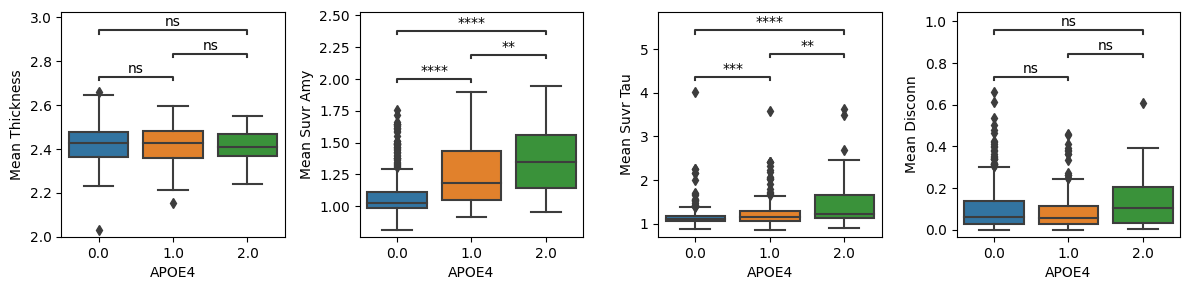

In [14]:
plot_group_comparison(
    data=df_m00,
    group_col="APOE4",
    group_name="APOE4",
    y_cols=["mean_thickness", "mean_SUVR_amy", "mean_SUVR_tau", "mean_disconn"],
    pairs=[(0, 1), (0, 2), (1, 2)],
    test="Mann-Whitney",
)

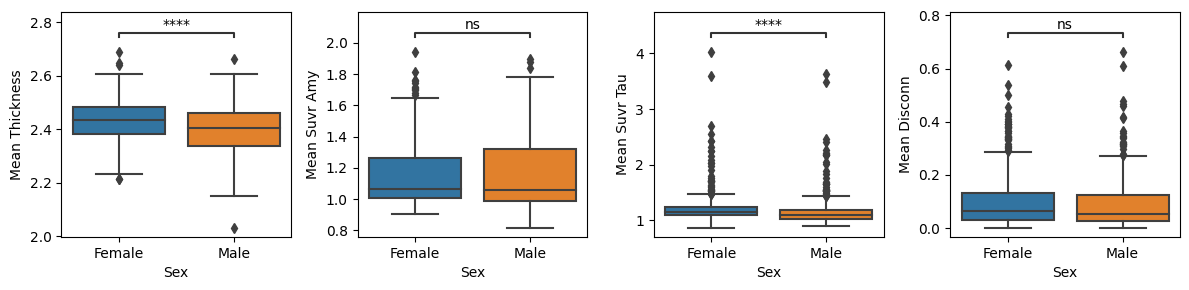

In [15]:
plot_group_comparison(
    data=df_m00,
    group_col="PTGENDER",
    group_name="Sex",
    y_cols=["mean_thickness", "mean_SUVR_amy", "mean_SUVR_tau", "mean_disconn"],
    pairs=[("Female", "Male")],
    test="Mann-Whitney",
)

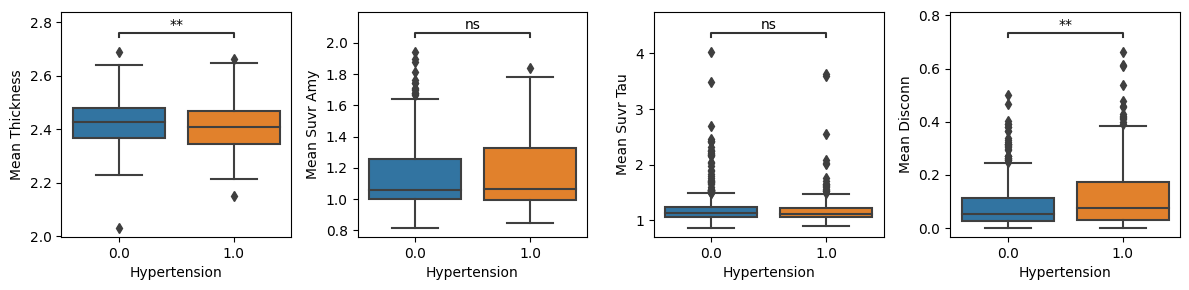

In [16]:
plot_group_comparison(
    data=df_m00,
    group_col="HMHYPERT",
    group_name="Hypertension",
    y_cols=["mean_thickness", "mean_SUVR_amy", "mean_SUVR_tau", "mean_disconn"],
    pairs=[(0, 1)],
    test="Mann-Whitney",
)

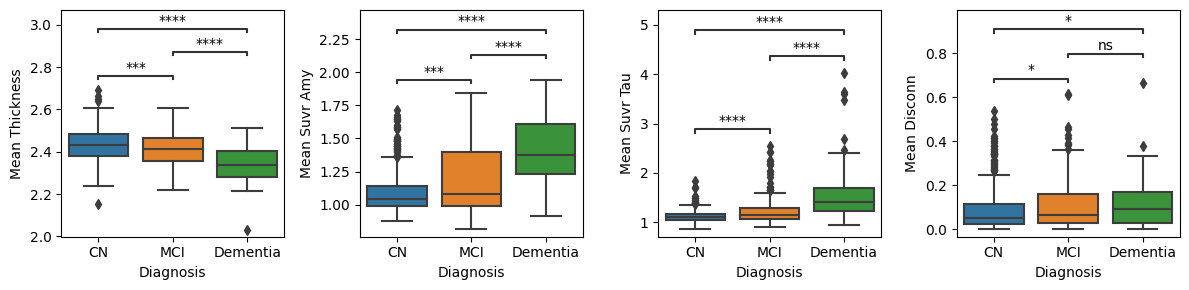

In [17]:
plot_group_comparison(
    data=df_m00,
    group_col="DX",
    group_name="Diagnosis",
    y_cols=["mean_thickness", "mean_SUVR_amy", "mean_SUVR_tau", "mean_disconn"],
    pairs=[("CN", "MCI"),
         ("CN", "Dementia"),
         ("MCI", "Dementia"),],
    test="Mann-Whitney",
)

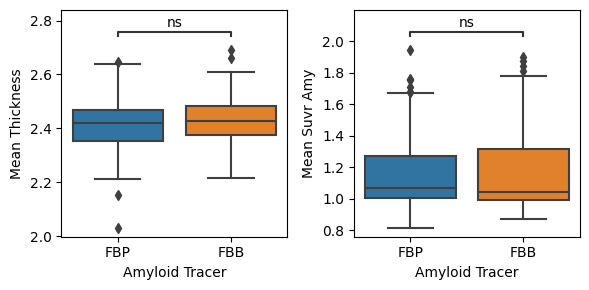

In [18]:
plot_group_comparison(
    data=df_m00,
    group_col="TRACER_amy",
    group_name="Amyloid Tracer",
    y_cols=["mean_thickness", "mean_SUVR_amy"],
    pairs=[("FBB", "FBP")],
    test="Mann-Whitney",
    figsize=(6,3)
)

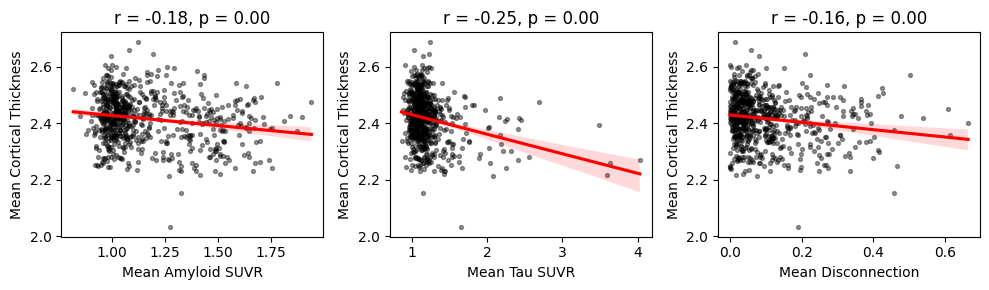

In [37]:
fig, axs = plt.subplots(1, 3, figsize = (10, 3))

my_regplot(data = df_m00, x = "mean_SUVR_amy", y = "mean_thickness", ax = axs[0])
my_regplot(data = df_m00, x = "mean_SUVR_tau", y = "mean_thickness", ax = axs[1])
my_regplot(data = df_m00, x = "mean_disconn", y = "mean_thickness", ax = axs[2])

axs[0].set_xlabel("Mean Amyloid SUVR")
axs[1].set_xlabel("Mean Tau SUVR")
axs[2].set_xlabel("Mean Disconnection")
axs[0].set_ylabel("Mean Cortical Thickness")
axs[1].set_ylabel("Mean Cortical Thickness")
axs[2].set_ylabel("Mean Cortical Thickness")

fig.tight_layout()

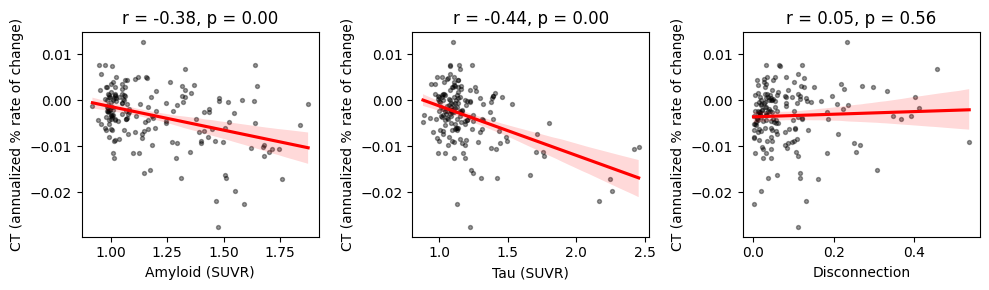

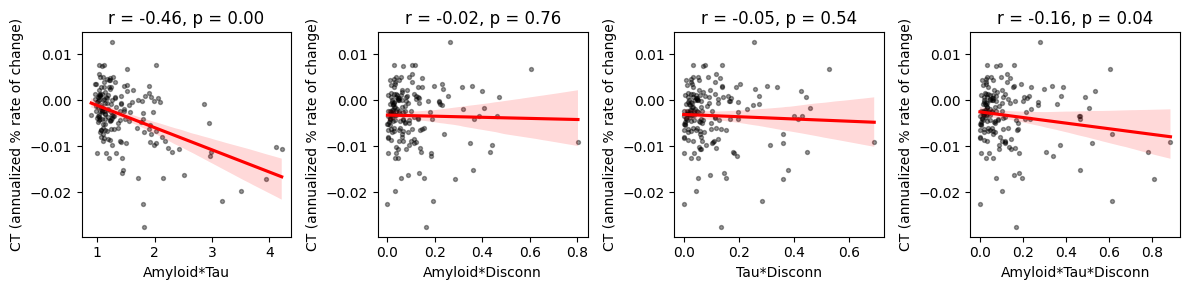

In [40]:
plot_correlation_biomarkers_ct(df_long_mean, "All", "All subjects", "thick_rate_year", is_rate=True)

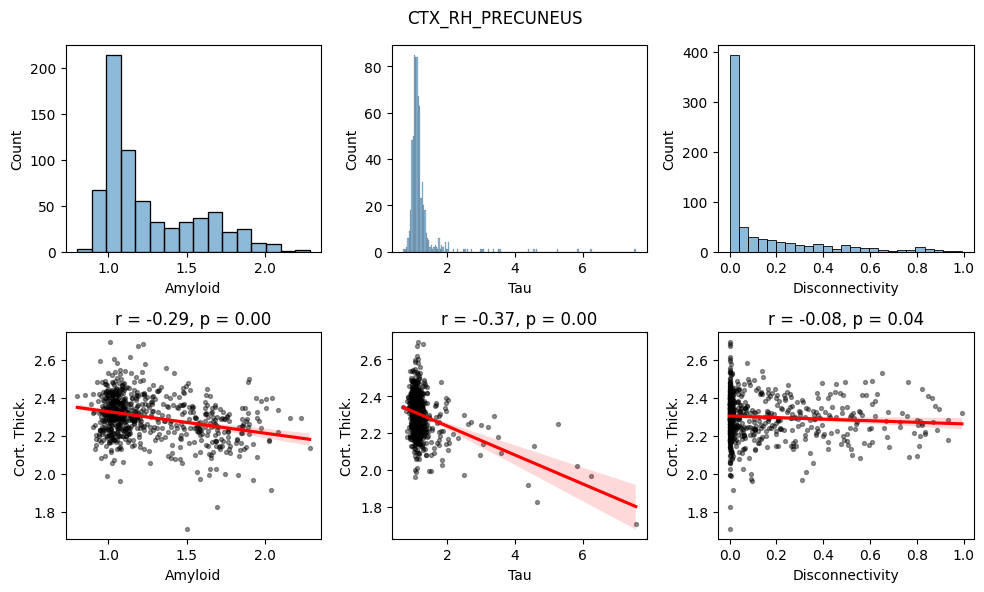

In [45]:
region_label = "CTX_RH_PRECUNEUS"
plot_analysis_one_region(df_m00, region_label)

In [22]:
# amyloid_plot_order = df_long.groupby('region')['SUVR_amy'].sum().sort_values(ascending=False).index.values
# tau_plot_order = df_long.groupby('region')['SUVR_tau'].sum().sort_values(ascending=False).index.values
# disconn_plot_order = df_long.groupby('region')['disconn'].sum().sort_values(ascending=False).index.values
# thickness_plot_order = df_long.groupby('region')['thickness_m00'].sum().sort_values(ascending=False).index.values


# fig, axs = plt.subplots(1, 4, figsize=(20, 5))

# sns.barplot(data=df_long, x="SUVR_amy", y="region", ax=axs[0], order=amyloid_plot_order[:20])
# sns.barplot(data=df_long, x="SUVR_tau", y="region", ax=axs[1], order=tau_plot_order[:20])
# sns.barplot(data=df_long, x="disconn", y="region", ax=axs[2], order=disconn_plot_order[:20])
# sns.barplot(data=df_long, x="thickness_m00", y="region", ax=axs[3], order=thickness_plot_order[:20])

# # Set y-tick labels and adjust the font size
# axs[0].set_yticklabels(axs[0].get_yticklabels(), fontsize=10)
# axs[1].set_yticklabels(axs[1].get_yticklabels(), fontsize=10)
# axs[2].set_yticklabels(axs[2].get_yticklabels(), fontsize=10)
# axs[3].set_yticklabels(axs[3].get_yticklabels(), fontsize=10)

# # Display the plot
# fig.tight_layout()


Brain plot saved to /home/leoner/Projects/cat_whim/reports/figures/Dementia_Amyloid_aparc.svg


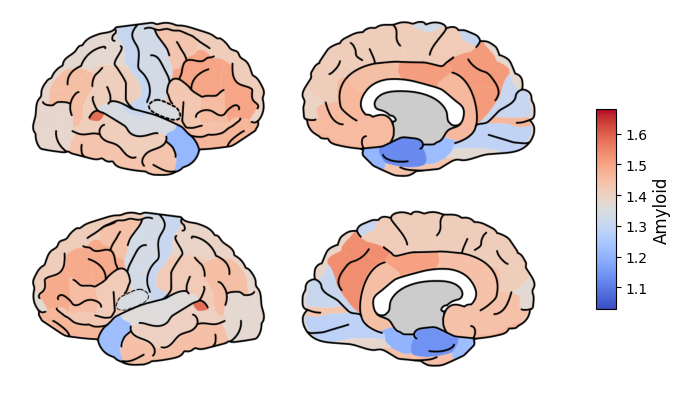

Brain plot saved to /home/leoner/Projects/cat_whim/reports/figures/Dementia_Tau_aparc.svg


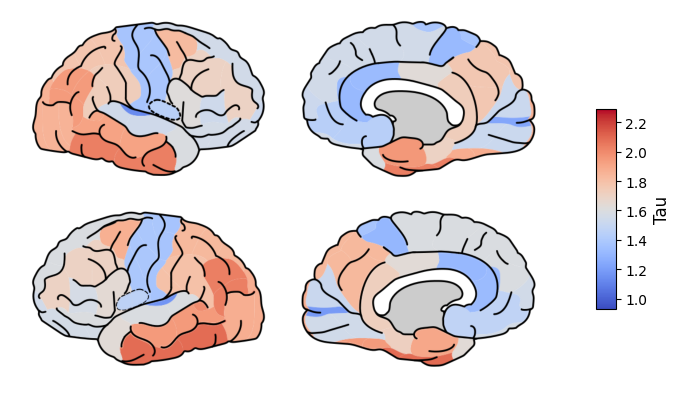

Brain plot saved to /home/leoner/Projects/cat_whim/reports/figures/Dementia_Disconnection_aparc.svg


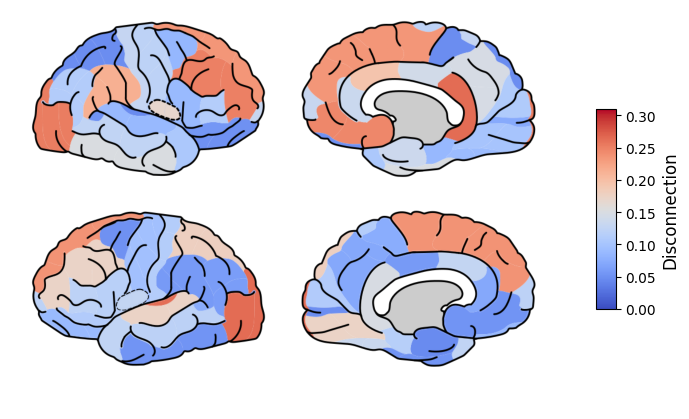

Brain plot saved to /home/leoner/Projects/cat_whim/reports/figures/Dementia_Cortical Thickness_aparc.svg


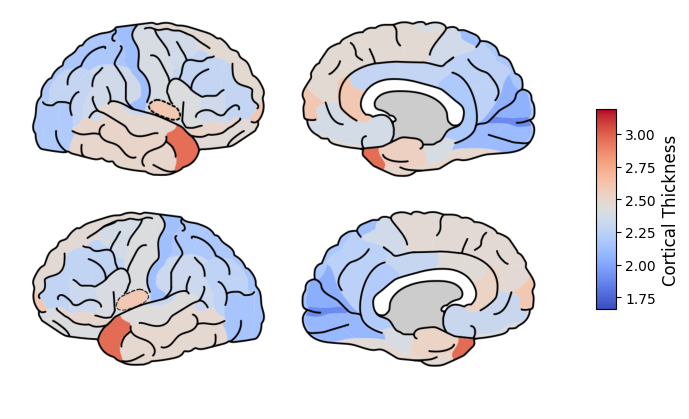

In [23]:
group = "Dementia"

if group == "All":
    df_brain = df.copy()
else:
    df_brain = df[df["DX"] == group].copy()

# Create the biomarker dictionary with the mean values
bmrkr_dict = {
    "Amyloid": df_brain[amy_cols].mean(axis=0).values,
    "Tau": df_brain[tau_cols].mean(axis=0).values,
    "Disconnection": df_brain[disconn_cols].mean(axis=0).values,
    "Cortical Thickness": df_brain[thick_cols].mean(axis=0).values
}


# Iterate over biomarkers and generate the brain plots
for bmrkr, values in bmrkr_dict.items():
    plot_brain_dk(group, bmrkr, values)   

# Cross-sectional analyses M00

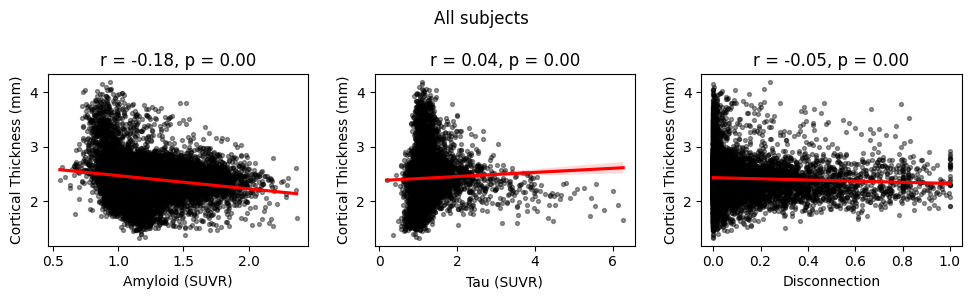

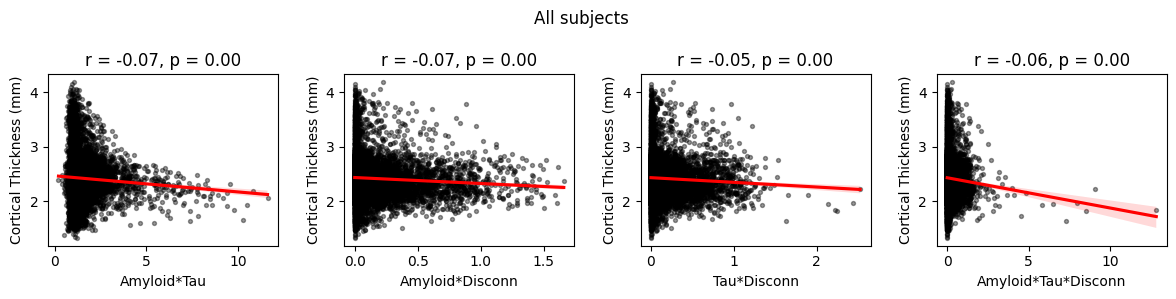

In [24]:
plot_correlation_biomarkers_ct(df_long_region, "All", "All subjects", "thickness_m00", is_rate=False)

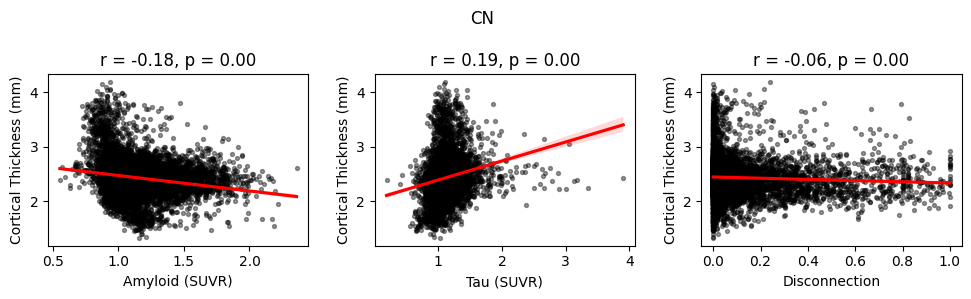

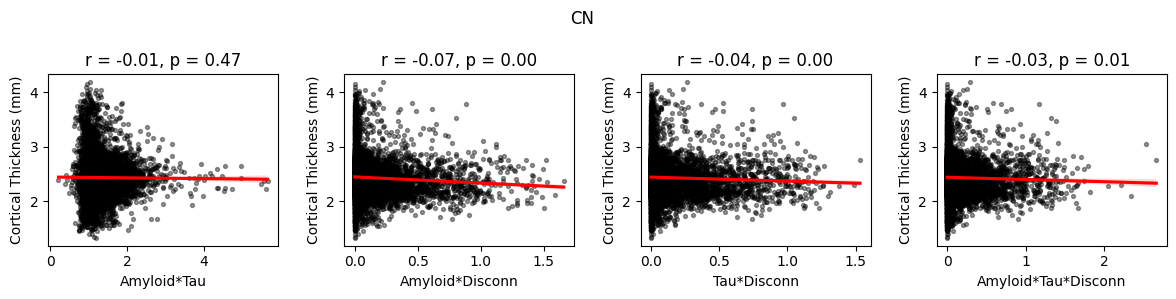

In [25]:
plot_correlation_biomarkers_ct(df_long_region, "CN", "CN", "thickness_m00")

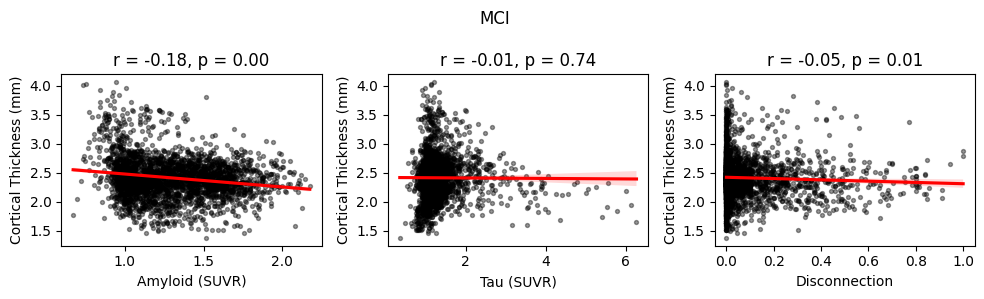

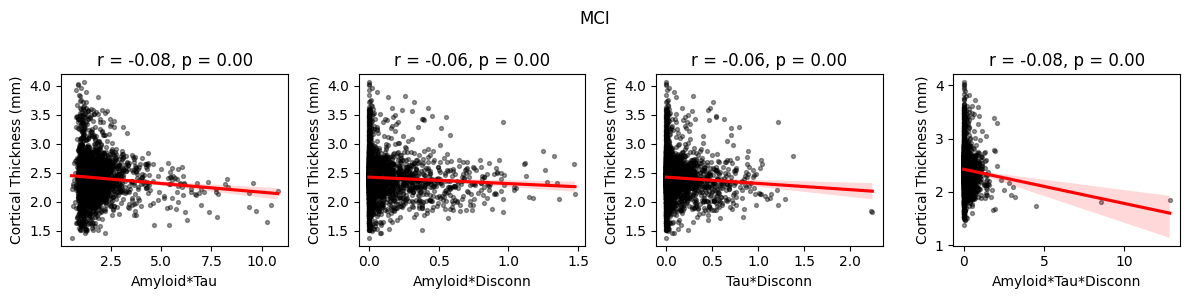

In [26]:
plot_correlation_biomarkers_ct(df_long_region, "MCI", "MCI", "thickness_m00")

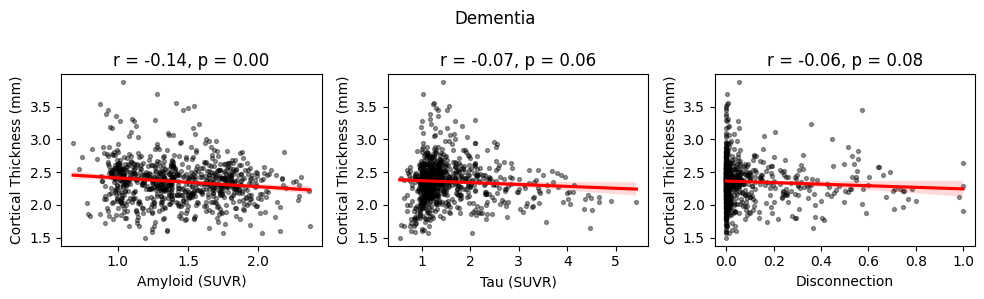

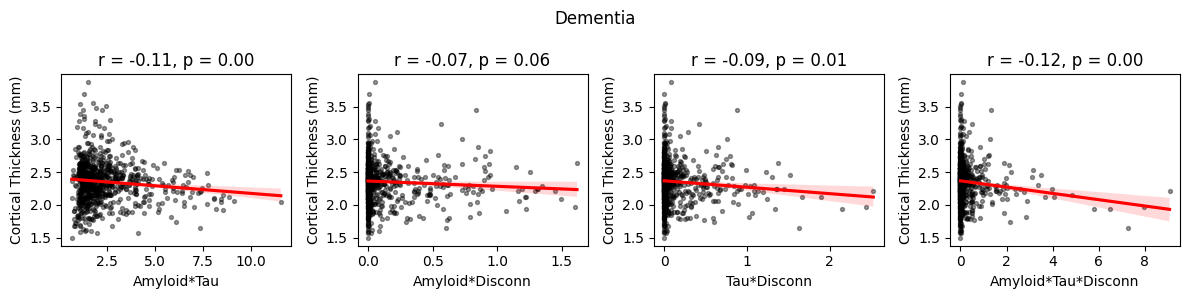

In [27]:
plot_correlation_biomarkers_ct(df_long_region, "Dementia", "Dementia", "thickness_m00")

# Reduction of CT per year

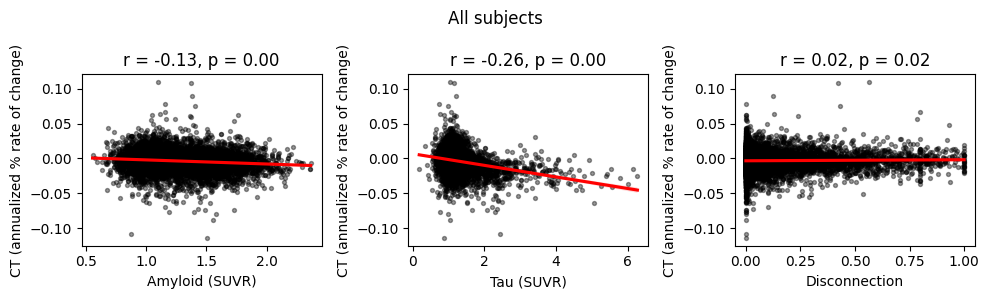

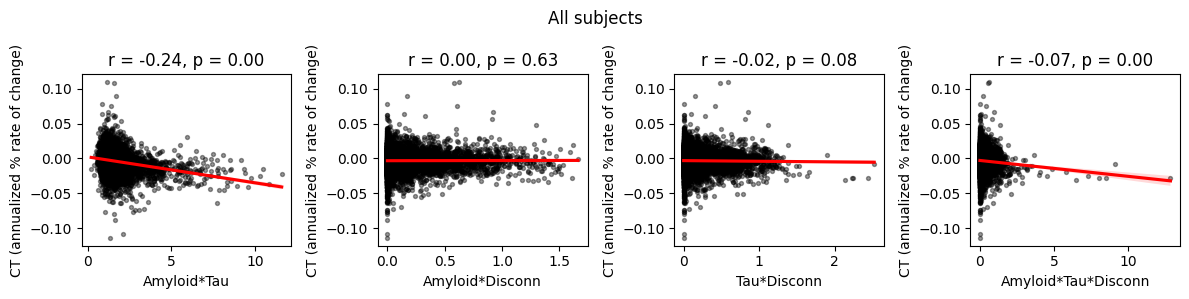

In [28]:
plot_correlation_biomarkers_ct(df_long_region, "All Subjects", "All subjects", "thick_rate_year", is_rate=True)

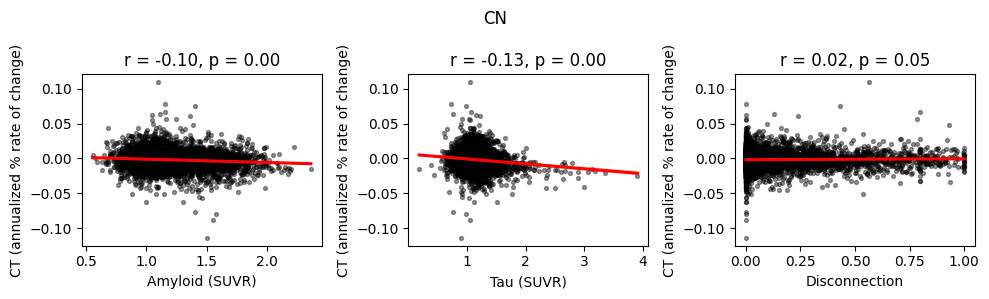

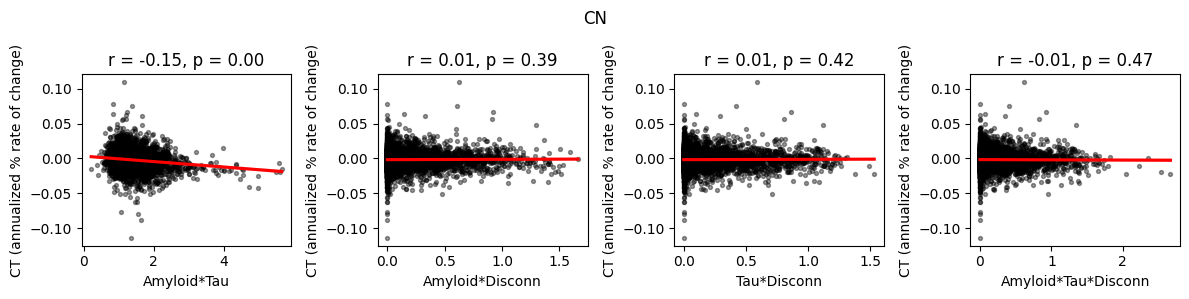

In [46]:
plot_correlation_biomarkers_ct(df_long_region, "CN", "CN", "thick_rate_year", is_rate=True)

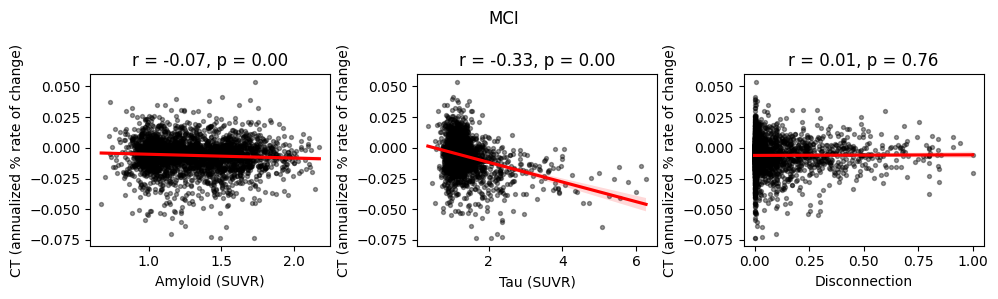

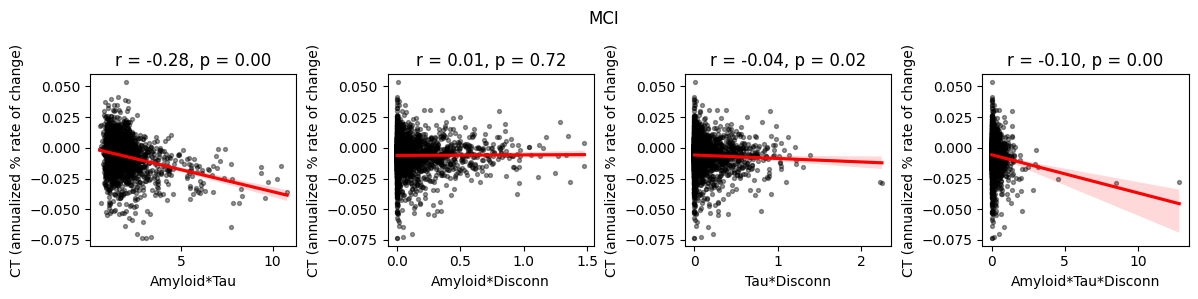

In [30]:
plot_correlation_biomarkers_ct(df_long_region, "MCI", "MCI", "thick_rate_year", is_rate=True)

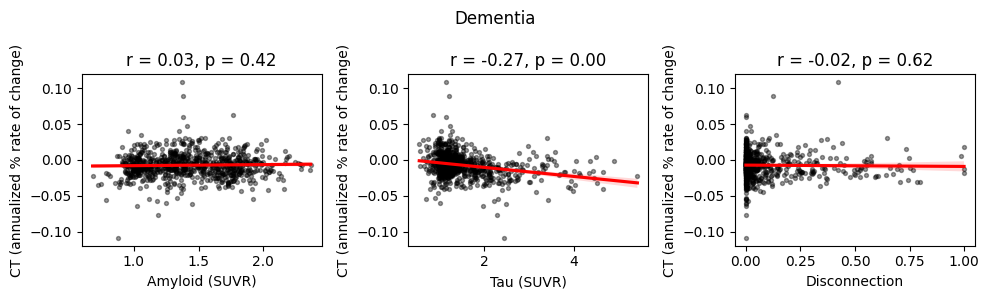

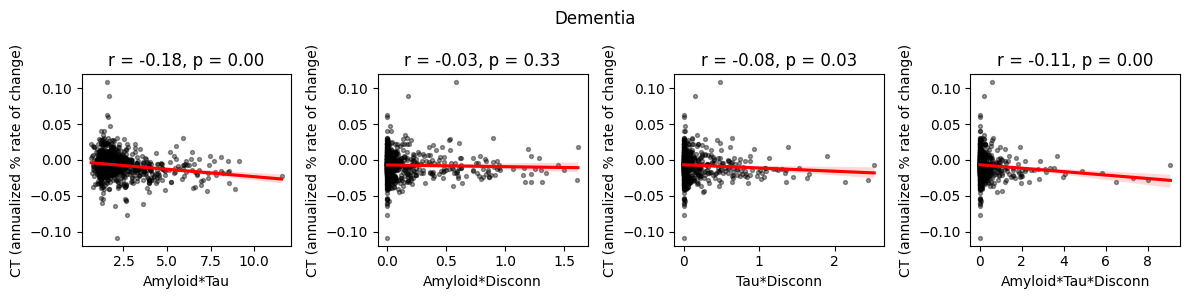

In [31]:
plot_correlation_biomarkers_ct(df_long_region, "Dementia", "Dementia", "thick_rate_year", is_rate=True)

In [32]:
# list_r = []
# list_p = []

# for region_label in dk_region_labels:

#     region_label_amy = region_label + "_SUVR_amy"
#     region_label_tau = region_label + "_SUVR_tau"
#     region_label_disconn = region_label + "_disconn"
#     region_label_thick = region_label + "_THICKNESS"

#     r, p = spearmanr(df[region_label_tau], df[region_label_thick])

#     list_r.append(r)
#     list_p.append(p)


# arr_p = np.array(list_p)
# arr_p_corr = false_discovery_control(arr_p)

# plot_brain_dk("All", "Disconn vs. CT", arr_p_corr)

In [33]:
# def plot_heatmap_correlation(df, bmrkr_cols, bmrkr_label, ax, prediction=False):
    
    
#     if prediction:
#         df_filt_ses_m01 = df[df["session"] == "M01"].copy()
#         df_filt_ses_m00 = df[(df["session"] == "M00") & (df["PTID"].isin(df_filt_ses_m01["PTID"]))].copy()
#         df_filt_ses_m01 = df_filt_ses_m01[df_filt_ses_m01["PTID"].isin(df_filt_ses_m00["PTID"])]
#         df_filt_ses_m01 = df_filt_ses_m01.drop_duplicates(subset="PTID")

#         thick_df = df_filt_ses_m01[thick_cols].reset_index(drop=True)
#         bmrkr_df = df_filt_ses_m00[bmrkr_cols].reset_index(drop=True)
    
#     else:

#         thick_df = df[thick_cols].reset_index(drop=True)
#         bmrkr_df = df[bmrkr_cols].reset_index(drop=True)

#     combined_df = pd.concat([thick_df, bmrkr_df], axis=1)
#     full_corr_matrix = combined_df.corr()
#     corr_matrix = full_corr_matrix.loc[thick_cols, bmrkr_cols]

#     sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, xticklabels=False, yticklabels=False, ax = ax)
#     ax.set_xlabel(bmrkr_label)
#     ax.set_ylabel('Cortical Thickness')

    
# # Heatmap of all vs. all regions correlations between biomarkers and cortical thickness

# fig, axs = plt.subplots(1, 3, figsize = (12, 3.5))

# plot_heatmap_correlation(df, amy_cols, "Amyloid SUVR", axs[0])
# plot_heatmap_correlation(df, tau_cols, "Tau SUVR", axs[1])
# plot_heatmap_correlation(df, disconn_cols, "Disconnections", axs[2])

# fig.suptitle("Baseline cross-sectional correlation")
# fig.tight_layout()

# fig, axs = plt.subplots(1, 3, figsize = (12, 3.5))

# # plot_heatmap_correlation(df, amy_cols, "Amyloid SUVR", axs[0], prediction=True)
# # plot_heatmap_correlation(df, tau_cols, "Tau SUVR", axs[1], prediction=True)
# # plot_heatmap_correlation(df, disconn_cols, "Disconnections", axs[2], prediction=True)

# # fig.suptitle("Baseline biomarker vs. M01 cort. thickness correlation")
# # fig.tight_layout()